# Exercise on regression for the course BERN02 

In this exercise, I have performed predictions with local regression using one predictor. The predictor is % of families with income < $3000 and the prediction will estimate total age-adjusted mortality rate per 100,000 people. 

The data used in this exercise is taken from here: https://github.com/luchem/bern02/tree/main/Labs. 
 - pollution_cleaneddata.csv contains the raw data 
 - pollution_metadata.csv contains metadata

First, packages used in the script are imported. The data is read and stored as a pandas DataFrame.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pooch import retrieve

# Read data, put in pandas dataframe
url = "https://raw.githubusercontent.com/luchem/bern02/refs/heads/main/Labs/pollution_cleaneddata.csv"
path = retrieve(url=url, known_hash="afe4fc434b080483990a1e88557695041964d9219892d2ad17d4d322de2d0a61")
df = pd.read_csv(path)

## Supporting functions
To support the main function performing the prediction, a few supporting functions are needed:
 - select_neighbouring_points()
 - weight()
 - weighted_rss()
 - rss()
 - create_weight_plot()

This first function is used to select the k nearest points using the squared difference between x0 and xi. These neighboring points are used to fit a local linear model around each target value. 

In [28]:
def select_neighboring_points(y, x, k, x0):
    # make a new array with the difference between x and x0 (squared)
    diff = (x - x0)**2 
    
    # get indices for the k smallest differences
    indices = np.argsort(diff)[:k]  
    
    # Return the k smallest values in x and y 
    return(x.iloc[indices], y.iloc[indices]) 

The weight function is used to assign weights to all xi. Points lying closer to x0 will have a larger weight, and therefore will have a bigger impact on the model fit. 

In [29]:
# Assigns a weight to each x_i depending on how close it lies to x_0
def weight(x, x0):
    # Weight is calculates using the squared difference between x and x0
    # If point is close: w is close to 1
    # If point is not close: w is close to 0
    return(1/((x - x0)**2 + 1))

The following two functions calculate Residual Sum of Squares (RSS) with or without weights. (The weights used are the ones created in the weight function above.)

In [30]:
def weighted_rss(beta, x, y, w):
    b0, b1 = beta
    return np.sum(w*(y - (b0 + b1*x))**2)
    
def rss(beta, x, y):
    b0, b1 = beta
    return np.sum((y - (b0 + b1*x))**2)


This function has the simple task och creating a plot to visualize the weight function used in the weighted_rss. Points that lie close to x0 are assigned a weight close to 1 and points that are further away are assigned weights closer to 0. 

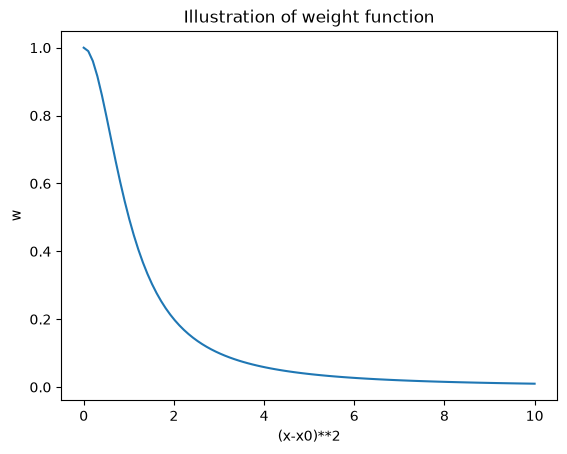

In [31]:
# Create plot to illustrate my weight function
def create_weight_plot():
    x = np.linspace(0, 10, num = 100)
    y = 1/(1+(x)**2)
    plt.plot(x,y)
    plt.title("Illustration of weight function")
    plt.xlabel("(x-x0)**2")
    plt.ylabel("w")
    plt.show()

create_weight_plot()
    

## Running the prediction
The predictions will be made for areas where the % of families with income < $3000 is 10 %, 18 % and 25 %. 

In [27]:
# Vector of values for which the prediction is going to be made
x0 = [10, 18, 25]

Finally, the local regression prediction is run with k=5 and the previously selected x-values for which the prediction is made. The results for the predicted values width standard deviation can be seen below. The full dataset (small blue points) including the k nearest points selected for each x0 (big orange, green and red points) and the predicted values (blue diamonds with errorbars) are illustrated in the plot. 

The following function performs the predictions with local regression using one predictor. 

In [32]:
def local_regression_prediction(y, x, k, x0):
    # Create plot to illustrate datapoints and selected local points
    plt.plot(x, y, ".", label = "Non-selected datapoints")
    plt.title("Visualization of datapoints")
    plt.xlabel("% of families with income < $3000")
    plt.ylabel("Total age-adjusted mortality rate per 100,000")
    
    # Create output lists
    pred = []
    se = []
    
    # Loop through the array x0 and fill arrays pred and se
    for i in range(len(x0)):
        # Select points close to x0
        local_x, local_y = select_neighboring_points(y, x, k, x0[i])
        
        # Mark selected points in plot
        plt.plot(local_x, local_y, "o", label = f"Selected points near x = {x0[i]}%")
       
        # Use optimization to estimate the local intercept and slope (b0 and b1)
        w = weight(local_x, x0[i])
        b0, b1 = minimize(weighted_rss, [0,0], args=(local_x, local_y, w)).x
               
        # Plug the estimated beta values into the model y = b0 + x*b1 to get predictions
        pred.append(b0 + b1*x0[i])
        
        # Calculate standard deviation using RSS with my predicted b0 and b1
        variance = np.sum((local_y - (b0 + b1*local_x))**2) / k 
        se.append(np.sqrt(variance)) 
        
    # Add predictions etc to plot
    plt.plot(x0, pred, "bD", label = "Predicted values")
    plt.errorbar(x0, pred, yerr = se, fmt = "bD", capsize = 5)
    plt.legend(bbox_to_anchor=(1.6, 0.7))
    plt.show()
    
    return(pred, se)

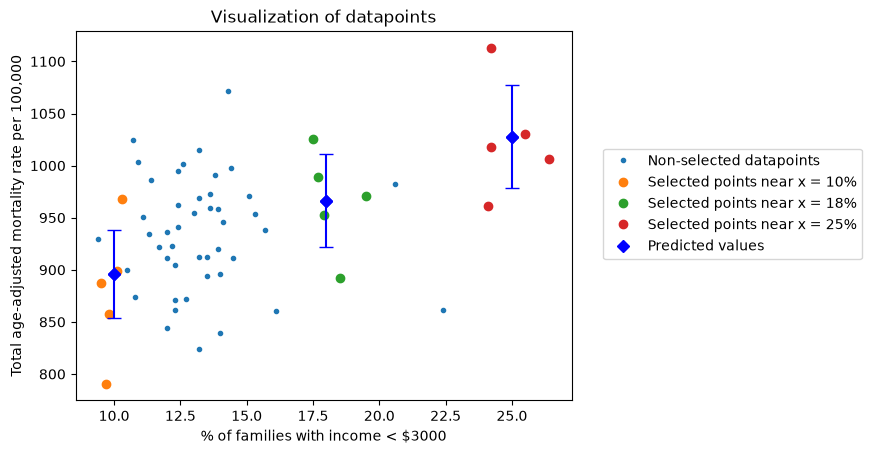

Predicted values (± SD) 
x = 10%: 896 ± 42
x = 18%: 966 ± 45
x = 25%: 1028 ± 49


In [33]:
# Run prediction
pred, se = local_regression_prediction(y = df["MORT"], 
                                       x = df["POOR"],
                                       k = 5, 
                                       x0 = x0)

# Print results of prediction
print("Predicted values (± SD) ")
for i in range(len(pred)):
    print(f"x = {x0[i]}%: {pred[i]:.0f} ± {se[i]:.0f}")

## FAIR data principles
In this project, I have used uv to set up and environment and keep track och dependencies and package versions. (Accessible, Reusable)

I have created a README-file that explains the context of the project, the aim of the project, where the data is from and where to find it. An improvement would be to download the datafiles to my own directory since the current storage depends on my teacher contiuously storing the data in the same location. This is somewhat backed up since information on the paper where the data is from is included. Could definately be improved further by adding a DOI. Another improvement would be to add appropriate equations in LaTeX format to further illustrate the models and methods used in my calculations. (Accesible, Reusable, Findable)

I have selected a license that is included as it's own file and referenced in the README-file. (Accessible, Reusable)

I have added explanations to my script and illustrative plots to show what I have done in the code, in addition to the prediction output. (Accessible, Reusable)

I have used jupyter notebook as a way to publish my work, and used data in csv-format. (Interoperable, Reusable, Accessible)

The project is saved in a public repository on GitHub. (Findable, Interoperable, Reusable, Accessible)


